In [11]:
import pandas as pd

df = pd.read_csv("../data/raw/Bhopal_NDVI_NDBI_Dataset.csv")
df.head()

,system:index,NDBI,NDVI,.geo
0,0,0.031976,0.253471,"{""type"":""Point"",""coordinates"":[77.362779546476..."
1,1,0.102853,0.112366,"{""type"":""Point"",""coordinates"":[77.455040506323..."
2,2,-0.065514,0.493861,"{""type"":""Point"",""coordinates"":[77.494086241541..."
3,3,0.019941,0.295933,"{""type"":""Point"",""coordinates"":[77.440537376795..."
4,4,0.108726,0.362501,"{""type"":""Point"",""coordinates"":[77.405126525388..."


In [13]:
df.shape

(1000, 4)

In [14]:
df.columns

Index(['system:index', 'NDBI', 'NDVI', '.geo'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  1000 non-null   int64  
 1   NDBI          1000 non-null   float64
 2   NDVI          1000 non-null   float64
 3   .geo          1000 non-null   object 
dtypes: float64(2), int64(1), object(1)
memory usage: 31.4+ KB


In [16]:
import json

In [17]:
def extract_coordinates(geo_string):
    geo = json.loads(geo_string)
    lon, lat = geo["coordinates"]
    return pd.Series([lat, lon])

In [18]:
df[["Latitude", "Longitude"]] = df[".geo"].apply(extract_coordinates)
df.head()

,system:index,NDBI,NDVI,.geo,Latitude,Longitude
0,0,0.031976,0.253471,"{""type"":""Point"",""coordinates"":[77.362779546476...",23.271867,77.362780
1,1,0.102853,0.112366,"{""type"":""Point"",""coordinates"":[77.455040506323...",23.182363,77.455041
2,2,-0.065514,0.493861,"{""type"":""Point"",""coordinates"":[77.494086241541...",23.232723,77.494086
3,3,0.019941,0.295933,"{""type"":""Point"",""coordinates"":[77.440537376795...",23.330404,77.440537
4,4,0.108726,0.362501,"{""type"":""Point"",""coordinates"":[77.405126525388...",23.212105,77.405127


In [19]:
df = df.drop(
    columns=[
        "system:index",
        ".geo"
    ]
)

In [20]:
df.head()

,NDBI,NDVI,Latitude,Longitude
0,0.031976,0.253471,23.271867,77.362780
1,0.102853,0.112366,23.182363,77.455041
2,-0.065514,0.493861,23.232723,77.494086
3,0.019941,0.295933,23.330404,77.440537
4,0.108726,0.362501,23.212105,77.405127


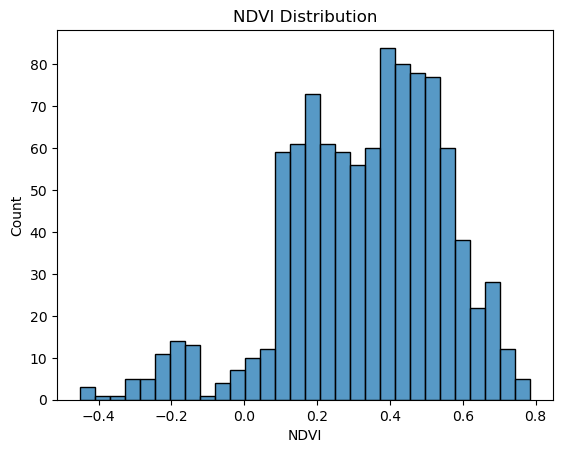

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["NDVI"], bins=30)

plt.title("NDVI Distribution")
plt.show()

In [ ]:
## NDVI Analysis

Most NDVI values lie between 0.2 and 0.6, indicating moderate vegetation cover across the study area.

A smaller number of locations exhibit negative NDVI values, representing barren or non-vegetated surfaces.

The presence of several locations with NDVI values above 0.6 suggests dense vegetation zones that may contribute to urban cooling.

Based on urban heat island studies, higher NDVI values are expected to correlate with lower land surface temperatures.

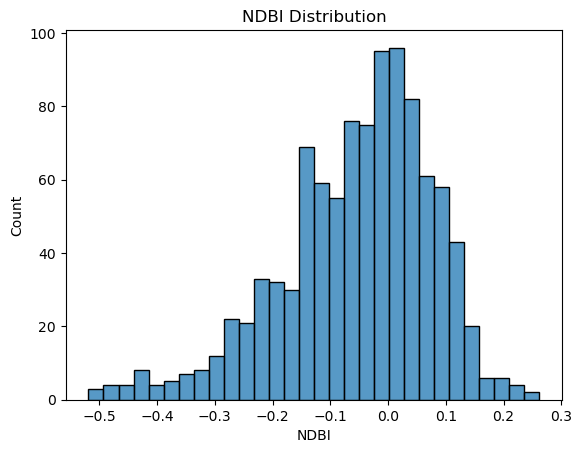

In [22]:
sns.histplot(df["NDBI"], bins=30)

plt.title("NDBI Distribution")
plt.show()

In [ ]:
# NDBI Analysis

Most NDBI values lie between -0.4 and 0.4, indicating a mix of built-up areas and natural surfaces across the study area.

A smaller number of locations exhibit negative NDBI values, representing water bodies or snow/ice.

The presence of several locations with NDBI values above 0.4 suggests areas with high impervious surface coverage that may contribute to urban heat islands.

Based on urban heat island studies, higher NDBI values are expected to correlate with higher land surface temperatures.

<Axes: xlabel='NDVI', ylabel='NDBI'>

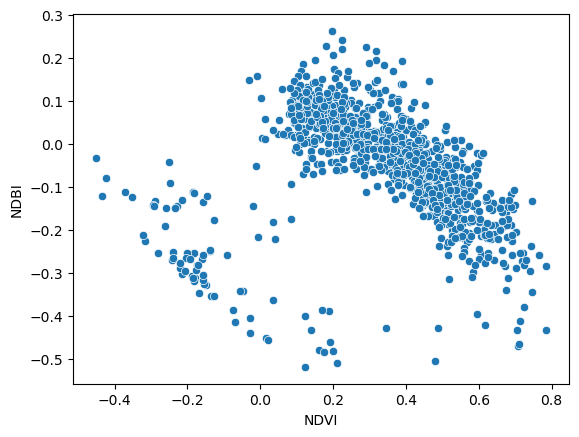

In [23]:
sns.scatterplot(
    data=df,
    x="NDVI",
    y="NDBI"
)

In [ ]:
# NDVI vs NDBI Scatter Plot
## NDVI-NDBI Relationship

The scatter plot reveals a clear inverse relationship between NDVI and NDBI.

Locations with higher vegetation cover generally exhibit lower built-up intensity, while highly built-up areas tend to have reduced vegetation.

This observation is consistent with urban heat island literature, where vegetation acts as a cooling factor and built-up surfaces contribute to heat accumulation.

<Axes: >

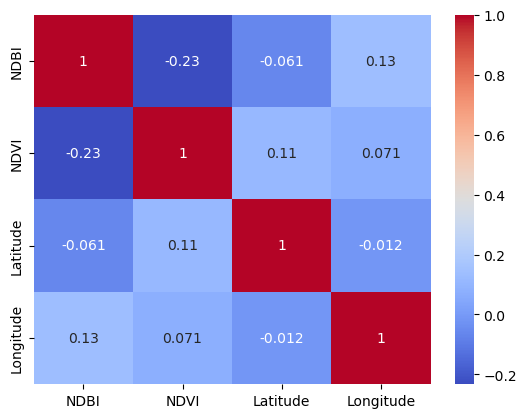

In [24]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [25]:
df.to_csv(
    "../data/processed/ndvi_ndbi_processed.csv",
    index=False
)

In [26]:
processed_df = pd.read_csv(
    "../data/processed/ndvi_ndbi_processed.csv"
)

processed_df.head()

,NDBI,NDVI,Latitude,Longitude
0,0.031976,0.253471,23.271867,77.362780
1,0.102853,0.112366,23.182363,77.455041
2,-0.065514,0.493861,23.232723,77.494086
3,0.019941,0.295933,23.330404,77.440537
4,0.108726,0.362501,23.212105,77.405127


In [27]:
processed_df.isnull().sum()

NDBI         0
NDVI         0
Latitude     0
Longitude    0
dtype: int64

In [28]:
processed_df[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,1000.000000,1000.000000
mean,23.259608,77.413977
std,0.045396,0.048064
min,23.171355,77.313311
25%,23.222547,77.375692
50%,23.258007,77.415257
75%,23.295923,77.453816
max,23.348011,77.505977


In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Bhopal_NDVI_NDBI_LST_Dataset.csv")

In [2]:
df.head()

,system:index,LST,NDBI,NDVI,.geo
0,0,31.156284,0.031976,0.253471,"{""type"":""Point"",""coordinates"":[77.362779546476..."
1,1,31.349402,0.102853,0.112366,"{""type"":""Point"",""coordinates"":[77.455040506323..."
2,2,29.766859,-0.065514,0.493861,"{""type"":""Point"",""coordinates"":[77.494086241541..."
3,3,31.711712,0.019941,0.295933,"{""type"":""Point"",""coordinates"":[77.440537376795..."
4,4,34.456382,0.108726,0.362501,"{""type"":""Point"",""coordinates"":[77.405126525388..."


In [3]:
df.shape

(1000, 5)

In [4]:
df.columns

Index(['system:index', 'LST', 'NDBI', 'NDVI', '.geo'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  1000 non-null   int64  
 1   LST           1000 non-null   float64
 2   NDBI          1000 non-null   float64
 3   NDVI          1000 non-null   float64
 4   .geo          1000 non-null   object 
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [6]:
df.isnull().sum()

system:index    0
LST             0
NDBI            0
NDVI            0
.geo            0
dtype: int64

In [7]:
df.describe()

,system:index,LST,NDBI,NDVI
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,30.398569,-0.054918,0.333069
std,288.819436,2.886746,0.131620,0.217896
min,0.000000,21.724258,-0.518683,-0.452088
25%,249.750000,29.153751,-0.133449,0.192491
50%,499.500000,30.783720,-0.034717,0.362226
75%,749.250000,32.159900,0.036066,0.493965
max,999.000000,37.739390,0.261856,0.785891


In [8]:
import json

def extract_coordinates(geo_string):
    geo = json.loads(geo_string)
    lon, lat = geo["coordinates"]
    return pd.Series([lat, lon])

df[["Latitude", "Longitude"]] = df[".geo"].apply(extract_coordinates)

In [9]:
df = df.drop(
    columns=[
        "system:index",
        ".geo"
    ]
)

In [10]:
df.to_csv(
    "../data/processed/final_dataset.csv",
    index=False
)

In [11]:
df.head()

,LST,NDBI,NDVI,Latitude,Longitude
0,31.156284,0.031976,0.253471,23.271867,77.362780
1,31.349402,0.102853,0.112366,23.182363,77.455041
2,29.766859,-0.065514,0.493861,23.232723,77.494086
3,31.711712,0.019941,0.295933,23.330404,77.440537
4,34.456382,0.108726,0.362501,23.212105,77.405127


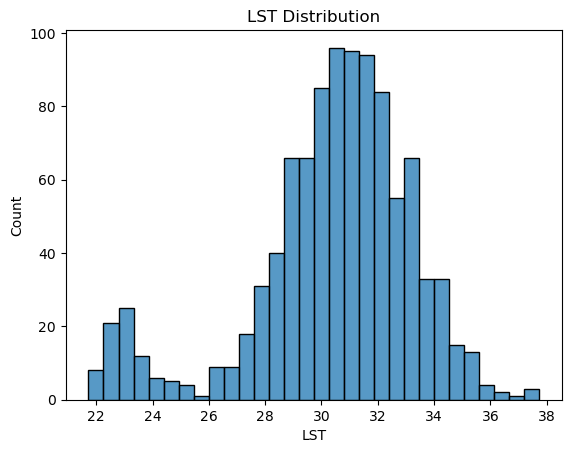

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["LST"], bins=30)

plt.title("LST Distribution")
plt.show()

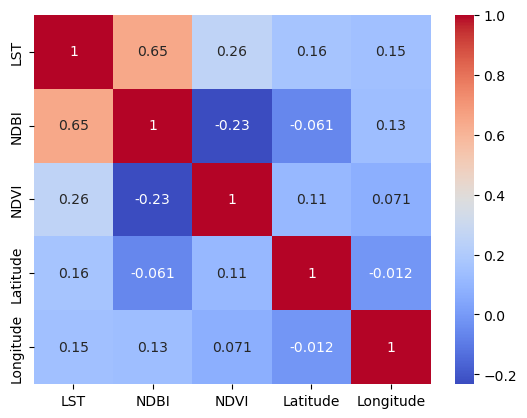

In [13]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [14]:
X = df[
    [
        "NDVI",
        "NDBI",
        "Latitude",
        "Longitude"
    ]
]

y = df["LST"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
predictions = model.predict(X_test)

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.1540547612427485
RMSE: 1.4757429127991766
R2: 0.697033643787542


In [27]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,NDVI,0.506689
1,NDBI,0.288702
3,Longitude,0.103211
2,Latitude,0.101398


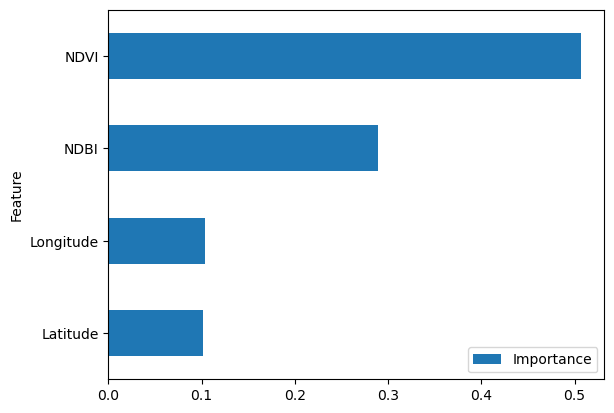

In [28]:
importance.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.show()

In [29]:
import joblib

joblib.dump(
    model,
    "../models/heat_model.pkl"
)

['../models/heat_model.pkl']

In [30]:
df.shape

(1000, 5)

In [31]:
df.isnull().sum()

LST          0
NDBI         0
NDVI         0
Latitude     0
Longitude    0
dtype: int64

In [32]:
corr = df.corr(numeric_only=True)
corr

,LST,NDBI,NDVI,Latitude,Longitude
LST,1.000000,0.647022,0.257214,0.163991,0.146280
NDBI,0.647022,1.000000,-0.232773,-0.060618,0.134556
NDVI,0.257214,-0.232773,1.000000,0.110760,0.071436
Latitude,0.163991,-0.060618,0.110760,1.000000,-0.012270
Longitude,0.146280,0.134556,0.071436,-0.012270,1.000000


In [33]:
X = df[
    [
        "NDVI",
        "NDBI",
        "Latitude",
        "Longitude"
    ]
]

y = df["LST"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
predictions = model.predict(X_test)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.1540547612427485
RMSE: 1.4757429127991766
R2: 0.697033643787542


In [38]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
0       NDVI    0.506689
1       NDBI    0.288702
3  Longitude    0.103211
2   Latitude    0.101398


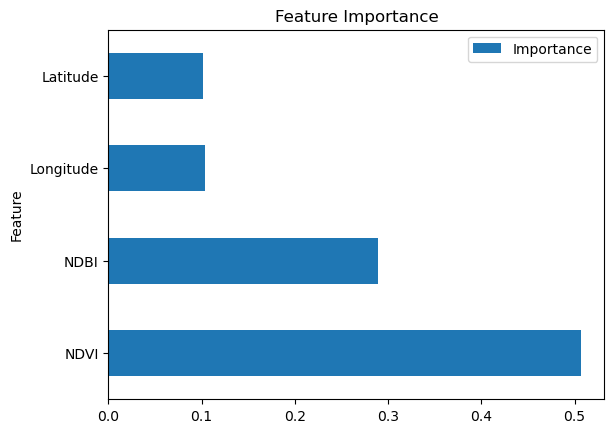

In [39]:
import matplotlib.pyplot as plt

importance.plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Feature Importance")
plt.show()

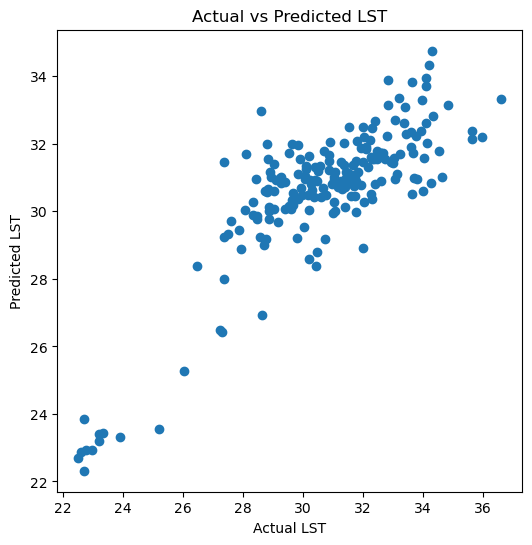

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")

plt.title("Actual vs Predicted LST")

plt.show()

In [41]:
import joblib

joblib.dump(
    model,
    "../models/heat_model.pkl"
)

['../models/heat_model.pkl']

In [42]:
def recommendation(ndvi, ndbi):
    if ndvi < 0.2:
        return "Increase vegetation cover"

    if ndbi > 0.1:
        return "Promote cool roofs and reflective materials"

    return "Maintain existing green infrastructure"

In [46]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [47]:
from inference.predictor import predict_heat

Model loaded successfully!


In [48]:
result = predict_heat(
    ndvi=0.15,
    ndbi=0.20,
    latitude=23.25,
    longitude=77.40
)

print(result)

{'predicted_temperature': np.float64(32.52), 'hotspot': np.False_, 'recommendation': 'Increase vegetation cover'}


In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,NDVI,0.506689
1,NDBI,0.288702
3,Longitude,0.103211
2,Latitude,0.101398


<Axes: ylabel='Feature'>

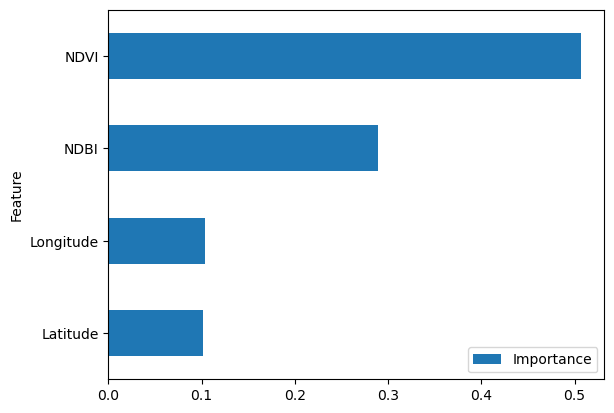

In [50]:
importance.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

In [51]:
# Sample Predictions for Dashboard
sample = df.head(20).copy()

sample["Predicted_LST"] = model.predict(
    sample[
        [
            "NDVI",
            "NDBI",
            "Latitude",
            "Longitude"
        ]
    ]
)

sample.to_csv(
    "../evaluation/sample_predictions.csv",
    index=False
)

sample.head()

,LST,NDBI,NDVI,Latitude,Longitude,Predicted_LST
0,31.156284,0.031976,0.253471,23.271867,77.362780,31.143928
1,31.349402,0.102853,0.112366,23.182363,77.455041,30.989732
2,29.766859,-0.065514,0.493861,23.232723,77.494086,30.114873
3,31.711712,0.019941,0.295933,23.330404,77.440537,31.548596
4,34.456382,0.108726,0.362501,23.212105,77.405127,33.459756


In [52]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

     Feature  Importance
0       NDVI    0.506689
1       NDBI    0.288702
3  Longitude    0.103211
2   Latitude    0.101398


In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,NDVI,0.506689
1,NDBI,0.288702
3,Longitude,0.103211
2,Latitude,0.101398
